### Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 200
import seaborn as sns
from scipy import stats
from scipy.stats import norm
import math
import os
from sklearn.cluster import KMeans
import geopandas as gpd

In [ ]:
import warnings
warnings.filterwarnings("ignore")

In [ ]:
pd.set_option('display.max_rows', 20)
pd.set_option('display.max_columns', 200)

### Read Dataset

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("tarunrm09/climate-change-indicators")

print("Path to dataset files:", path)

100%|██████████| 34.0k/34.0k [00:00<00:00, 16.5MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/tarunrm09/climate-change-indicators/versions/1


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving climate_change_indicators.csv to climate_change_indicators.csv


In [ ]:
df = pd.read_csv('climate_change_indicators.csv')

df.head()

,ObjectId,Country,ISO2,ISO3,Indicator,Unit,Source,CTS_Code,CTS_Name,CTS_Full_Descriptor,F1961,F1962,F1963,F1964,F1965,F1966,F1967,F1968,F1969,F1970,F1971,F1972,F1973,F1974,F1975,F1976,F1977,F1978,F1979,F1980,F1981,F1982,F1983,F1984,F1985,F1986,F1987,F1988,F1989,F1990,F1991,F1992,F1993,F1994,F1995,F1996,F1997,F1998,F1999,F2000,F2001,F2002,F2003,F2004,F2005,F2006,F2007,F2008,F2009,F2010,F2011,F2012,F2013,F2014,F2015,F2016,F2017,F2018,F2019,F2020,F2021,F2022
0,1,"Afghanistan, Islamic Rep. of",AF,AFG,Temperature change with respect to a baseline ...,Degree Celsius,Food and Agriculture Organization of the Unite...,ECCS,Surface Temperature Change,"Environment, Climate Change, Climate Indicator...",-0.113,-0.164,0.847,-0.764,-0.244,0.226,-0.371,-0.423,-0.539,0.813,0.619,-1.124,0.232,-0.489,-0.445,-0.286,0.513,0.129,0.361,0.600,0.483,-0.346,0.164,0.145,0.283,-0.141,0.391,0.919,-0.205,0.730,-0.168,-0.294,0.220,0.430,0.359,-0.116,0.471,0.675,1.198,0.993,1.311,1.365,0.587,1.373,0.401,1.720,0.675,0.704,0.895,1.613,1.397,0.223,1.281,0.456,1.093,1.555,1.540,1.544,0.910,0.498,1.327,2.012
1,2,Albania,AL,ALB,Temperature change with respect to a baseline ...,Degree Celsius,Food and Agriculture Organization of the Unite...,ECCS,Surface Temperature Change,"Environment, Climate Change, Climate Indicator...",0.627,0.326,0.075,-0.166,-0.388,0.559,-0.074,0.081,-0.013,-0.106,-0.195,-0.069,-0.288,-0.139,-0.211,-0.683,0.545,-0.814,0.203,-0.414,-0.351,0.173,-0.128,-0.270,-0.103,0.569,-0.106,0.370,-0.066,0.795,-0.269,0.106,0.076,1.330,-0.172,-0.038,0.075,0.795,0.670,1.065,1.532,0.492,0.970,0.444,0.189,0.345,1.316,0.978,0.910,1.191,1.055,1.487,1.333,1.198,1.569,1.464,1.121,2.028,1.675,1.498,1.536,1.518
2,3,Algeria,DZ,DZA,Temperature change with respect to a baseline ...,Degree Celsius,Food and Agriculture Organization of the Unite...,ECCS,Surface Temperature Change,"Environment, Climate Change, Climate Indicator...",0.164,0.114,0.077,0.250,-0.100,0.433,-0.026,-0.067,0.291,0.116,-0.385,-0.348,-0.015,-0.503,-0.539,-0.782,0.504,0.012,0.654,0.232,0.215,0.399,0.560,-0.004,0.508,0.296,0.975,1.304,0.386,1.266,0.031,-0.312,0.552,0.732,0.595,0.846,1.059,1.109,1.476,0.820,1.856,1.258,1.585,0.988,1.264,1.395,1.220,1.185,0.945,2.265,1.398,1.147,1.192,1.690,1.121,1.757,1.512,1.210,1.115,1.926,2.330,1.688
3,4,American Samoa,AS,ASM,Temperature change with respect to a baseline ...,Degree Celsius,Food and Agriculture Organization of the Unite...,ECCS,Surface Temperature Change,"Environment, Climate Change, Climate Indicator...",0.079,-0.042,0.169,-0.140,-0.562,0.181,-0.368,-0.187,0.132,-0.047,-0.477,-0.067,0.330,-0.308,-0.118,-0.177,0.156,0.092,0.341,0.350,0.179,0.280,0.313,0.277,0.256,0.394,0.354,0.509,0.143,0.497,0.641,0.344,-0.069,0.189,0.755,0.784,NaN,NaN,0.242,0.626,0.904,1.152,0.716,0.191,0.801,0.403,1.032,0.670,NaN,1.311,0.854,0.924,1.257,1.170,1.009,1.539,1.435,1.189,1.539,1.430,1.268,1.256
4,5,"Andorra, Principality of",AD,AND,Temperature change with respect to a baseline ...,Degree Celsius,Food and Agriculture Organization of the Unite...,ECCS,Surface Temperature Change,"Environment, Climate Change, Climate Indicator...",0.736,0.112,-0.752,0.308,-0.490,0.415,0.637,0.018,-0.137,0.121,-0.326,-0.499,0.025,-0.371,0.246,-0.045,-0.093,-0.163,0.058,-0.188,0.178,1.044,0.859,-0.157,0.059,0.387,0.397,0.883,1.162,1.736,0.231,0.386,0.174,1.508,1.279,0.570,1.788,1.018,1.055,1.050,1.480,0.835,1.949,0.936,0.851,1.485,1.024,0.946,1.413,0.471,1.677,1.265,0.831,1.946,1.690,1.990,1.925,1.919,1.964,2.562,1.533,3.243


### Cleaning Data

In [ ]:
# subsetting
df = df[[
    'Country',
    'ISO3',
    'F1961', 'F1962',
    'F1963', 'F1964', 'F1965', 'F1966', 'F1967', 'F1968', 'F1969', 'F1970',
    'F1971', 'F1972', 'F1973', 'F1974', 'F1975', 'F1976', 'F1977', 'F1978',
    'F1979', 'F1980', 'F1981', 'F1982', 'F1983', 'F1984', 'F1985', 'F1986',
    'F1987', 'F1988', 'F1989', 'F1990', 'F1991', 'F1992', 'F1993', 'F1994',
    'F1995', 'F1996', 'F1997', 'F1998', 'F1999', 'F2000', 'F2001', 'F2002',
    'F2003', 'F2004', 'F2005', 'F2006', 'F2007', 'F2008', 'F2009', 'F2010',
    'F2011', 'F2012', 'F2013', 'F2014', 'F2015', 'F2016', 'F2017', 'F2018',
    'F2019', 'F2020', 'F2021', 'F2022'
]].copy()

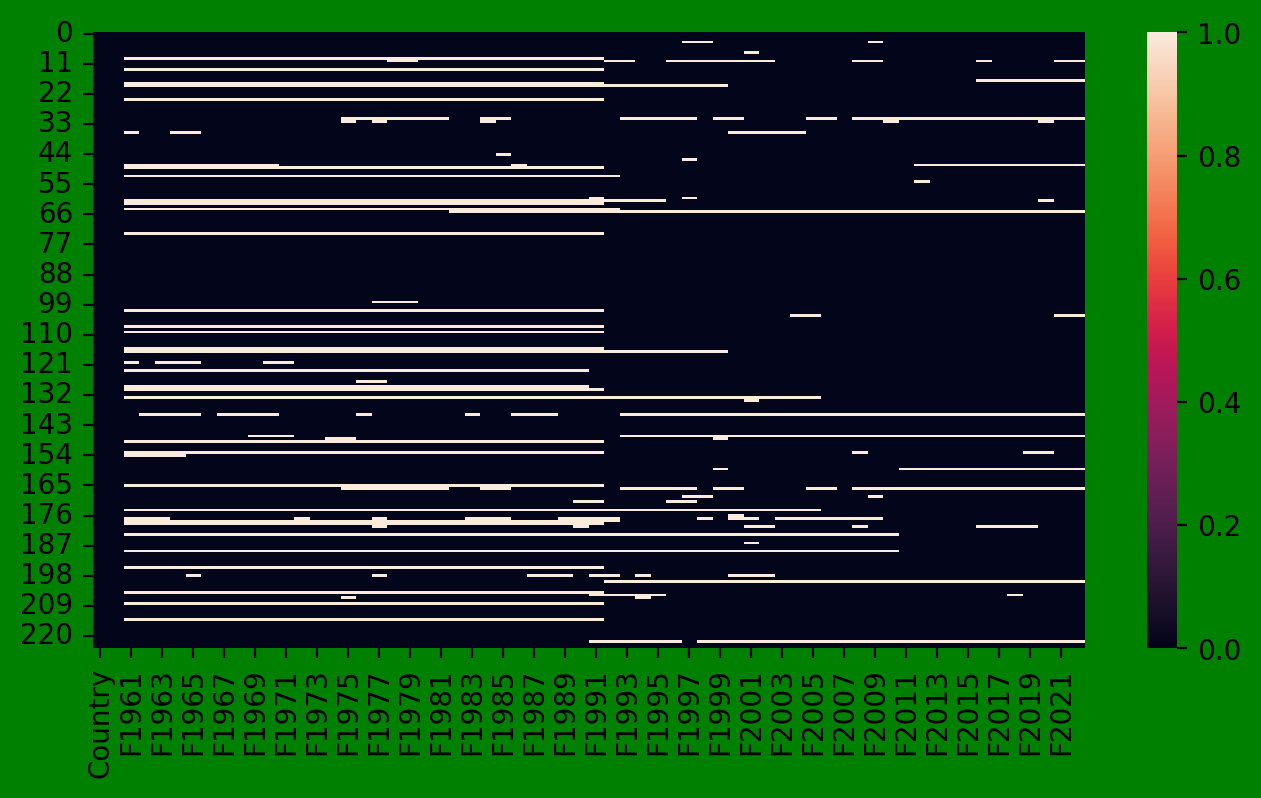

In [ ]:
plt.figure(figsize = (8, 4), facecolor = "green")

sns.heatmap(
    df.isnull(), vmin = 0, vmax = 1
)

plt.show()

In [ ]:
# checking for missing rows
df.isnull().sum()[[
    'F1990', 'F1991', 'F1992', 'F1993'
]]

,0
F1990,36
F1991,37
F1992,17
F1993,16


In [ ]:
df_dim = df[[
    'Country', 'ISO3',
    'F1992', 'F2002', 'F2012', 'F2022'
]]
df_dim.head()

,Country,ISO3,F1992,F2002,F2012,F2022
0,"Afghanistan, Islamic Rep. of",AFG,-0.294,1.365,0.223,2.012
1,Albania,ALB,0.106,0.492,1.487,1.518
2,Algeria,DZA,-0.312,1.258,1.147,1.688
3,American Samoa,ASM,0.344,1.152,0.924,1.256
4,"Andorra, Principality of",AND,0.386,0.835,1.265,3.243


In [ ]:
df_dim = df_dim.dropna().reset_index(drop = True).copy()

### Grouping

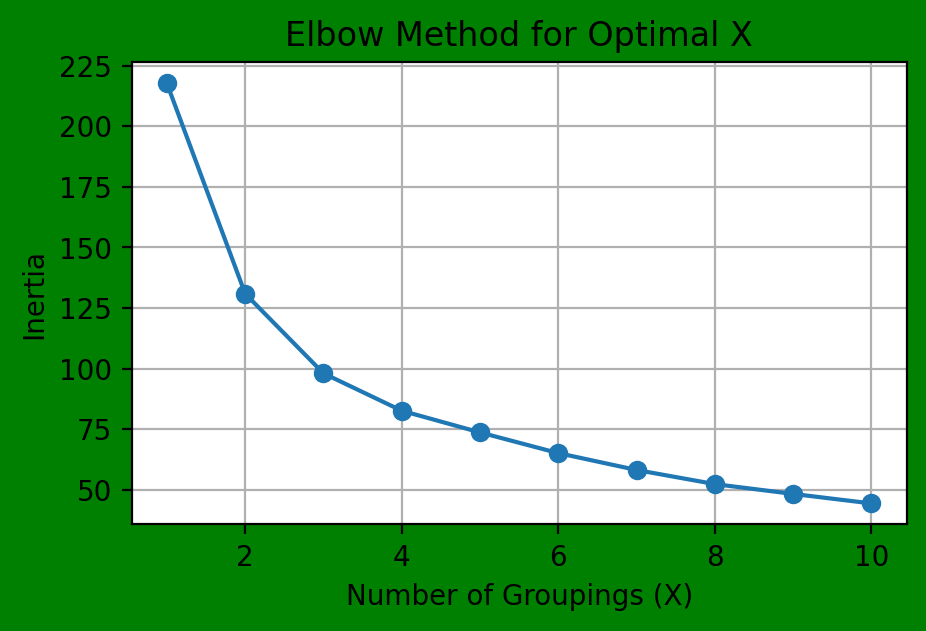

In [ ]:
# choosing columns for grouping
I = df_dim.iloc[:, 2:]
list_inertia = []
X_range = range(1, 11)

#calculating inertia
for X in X_range:
    Xmeans = KMeans(n_clusters = X, n_init = 10, random_state = 84)
    Xmeans.fit(I)
    list_inertia.append(Xmeans.inertia_)

#plot
plt.figure(figsize = (5, 3), facecolor = "green")
plt.plot(X_range, list_inertia, marker = "o", linestyle = '-')
plt.xlabel('Number of Groupings (X)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal X')
plt.grid(True)
plt.show()

In [ ]:
n_clusters = 3
kmeans = KMeans(n_clusters = n_clusters, n_init = 10, random_state = 84)
df_dim['Cluster'] = kmeans.fit_predict(I)

#showings the clustered area
display(df_dim)

,Country,ISO3,F1992,F2002,F2012,F2022,Cluster
0,"Afghanistan, Islamic Rep. of",AFG,-0.294,1.365,0.223,2.012,0
1,Albania,ALB,0.106,0.492,1.487,1.518,1
2,Algeria,DZA,-0.312,1.258,1.147,1.688,0
3,American Samoa,ASM,0.344,1.152,0.924,1.256,1
4,"Andorra, Principality of",AND,0.386,0.835,1.265,3.243,2
...,...,...,...,...,...,...,...
192,West Bank and Gaza,PSE,-1.045,0.728,1.043,1.074,0
193,Western Sahara,ESH,0.529,1.249,1.344,1.970,2
194,World,WLD,0.184,1.021,1.074,1.394,1
195,Zambia,ZMB,0.544,0.711,0.972,0.686,1


### Exploration

In [ ]:
#descriptive stats
df_dim['Cluster'].value_counts()

,count
Cluster,
1,125
2,48
0,24


In [ ]:
# table displaying statistics of clusters
df_table_stats = df_dim.groupby('Cluster').agg({
    'F1992': ['std', 'mean', 'min', 'max'],
    'F2002': ['std', 'mean', 'min', 'max'],
    'F2012': ['std', 'mean', 'min', 'max'],
    'F2022': ['std', 'mean', 'min', 'max'],
}).round(3)
display(df_table_stats.T)

Cluster         0      1      2
F1992 std   0.384  0.350  0.457
      mean -0.798  0.262  0.705
      min  -1.344 -0.716 -0.059
      max   0.100  1.147  1.601
F2002 std   0.404  0.224  0.352
      mean  1.039  0.740  1.332
      min   0.009  0.017  0.681
      max   1.716  1.380  2.255
F2012 std   0.459  0.251  0.428
      mean  1.178  0.672  1.314
      min  -0.032 -0.128  0.230
      max   2.144  1.487  2.089
F2022 std   0.415  0.427  0.356
      mean  1.636  0.991  2.218
      min   1.040 -1.305  1.405
      max   2.370  1.840  3.243

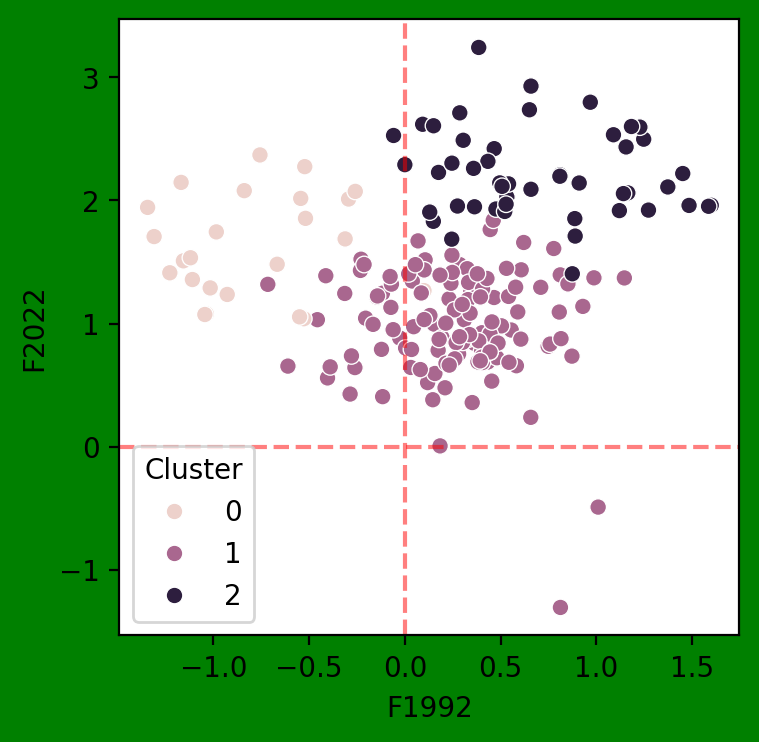

In [ ]:
plt.figure(figsize = (4, 4), facecolor = "green")
sns.scatterplot(
    data = df_dim,
    x = 'F1992', y = 'F2022',
    hue = 'Cluster'
)
plt.axhline(
    0, 0, 1,
    color = "red", linestyle = "--", alpha = 0.5
)
plt.axvline(
    0, 0, 1,
    color = "red", linestyle = "--", alpha = 0.5
)
plt.show()